# Rough Heston / American Puts Price Production Audit 01

Validate the first 100 production rows with the four independent engines.

## Load Data And Timings

Load the production audit and display the common four-engine timing view.

,wall seconds,kernel seconds
engine,,
cpp cuda,4.55,4.54
pytorch gpu,8.555,-
cpp cpu,20.91,-
pytorch cpu,46.41,-


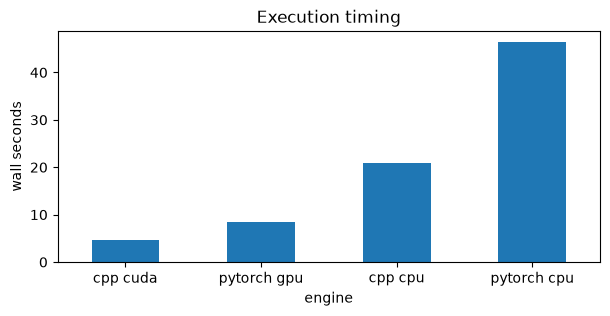

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "registry").is_dir())
PROJECT_ROOT = ROOT
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src_python") not in sys.path:
    sys.path.insert(0, str(ROOT / "src_python"))

from tools.validation.audit import load_production_audit, timing_frame

pd.set_option("display.precision", 4)
audit = load_production_audit(
    ROOT,
    model_family='rough_heston',
    product_family='american_puts',
    delta_crn=False,
)
cpp_gpu = audit.validation["cpp_gpu"].data
python_gpu = audit.validation["python_gpu"].data
cpp_cpu = audit.validation["cpp_cpu"].data
python_cpu = audit.validation["python_cpu"].data
cpp_gpu_spec = audit.validation["cpp_gpu"].specification
cpp_gpu_spec_summary = cpp_gpu_spec["summary"]
production = audit.production.data
production_head = production["results"][:100]
data = {key: document.data for key, document in audit.validation.items()}
specs = {key: document.specification for key, document in audit.validation.items()}
paths = {key: document.json_path for key, document in audit.validation.items()}
spec_paths = {key: document.yaml_path for key, document in audit.validation.items()}
spec_path = spec_paths["cpp_gpu"]
result_path = paths["cpp_gpu"]
PRODUCT_FAMILY = 'american_puts'
performance = timing_frame(audit)
benchmark_row_count = performance.attrs.get("benchmark_row_count")
if benchmark_row_count and benchmark_row_count != 100:
    print(
        f"Performance timing uses one hot call over {benchmark_row_count:,} "
        "benchmark rows; correctness retains the 100-row audit slice."
    )
display(performance.style.format("{:.4g}", na_rep="-"))
ax = performance["wall seconds"].plot(kind="bar", figsize=(7, 3), rot=0)
ax.set_ylabel("wall seconds")
ax.set_title("Execution timing")
plt.show()

## Dataset Coherence

Apply the production, native reproducibility, and statistical checks.

In [2]:
from tools.validation.audit import coherence_frame

coherence = coherence_frame(audit)
display(
    coherence.style.format(
        {
            "max abs error": "{:.3e}",
            "max rel error (%)": "{:.3f}",
            "max z-score": "{:.3f}",
        },
        na_rep="-",
    )
)

,output,max abs error,max rel error (%),relative rows,max z-score
check,,,,,
production stored cpp cuda vs regenerated cpp cuda,price,0.000e+00,0.000,100,0.000
cpp cpu vs cpp cuda,price,4.480e-14,0.000,100,0.000
pytorch cpu vs pytorch gpu,price,5.969e-03,5.653,100,2.227
cpp cuda vs pytorch gpu,price,5.219e-03,4.729,100,2.844


## Path Reconstruction Check

Reconstruct the exact Philox paths for one production row and reprice it.

In [3]:
from tools.paths.rough_heston import (
    price_american_put_from_paths,
    reconstruct_state_paths_for_result,
)

row_id = "000001"
result_json = ROOT / "registry/production/results/rough_heston/american_puts/data/rough_heston_01__american_puts_01__cpp_gpu_philox_01.json"
result_yaml = ROOT / "registry/production/results/rough_heston/american_puts/specifications/rough_heston_01__american_puts_01__cpp_gpu_philox_01.yaml"

try:
    paths, factor_paths, kernel_seconds, stored_row, model, product, spec = reconstruct_state_paths_for_result(
        result_json_path=result_json,
        result_yaml_path=result_yaml,
        row_id=row_id,
        use_gpu=False,
    )
    repriced = price_american_put_from_paths(
        paths,
        factor_paths=factor_paths,
        theta=float(model["theta"]),
        strike=float(product["strike"]),
        maturity=float(product["maturity"]),
        rate=float(model["risk_free_rate"]),
    )
    stored = stored_row["outputs"]
    path_check_df = pd.DataFrame([
        {
            "row": row_id,
            "stored price": stored["price"],
            "repriced price": repriced["price"],
            "abs error": abs(stored["price"] - repriced["price"]),
            "stored stderr": stored["standard_error"],
            "repriced stderr": repriced["standard_error"],
        }
    ])
    display(path_check_df.style.format({
        "stored price": "{:.6f}",
        "repriced price": "{:.6f}",
        "abs error": "{:.3e}",
        "stored stderr": "{:.6f}",
        "repriced stderr": "{:.6f}",
    }))
except Exception as exc:
    display(Markdown(f"**Path-export repricing check skipped.** {exc}"))

,row,stored price,repriced price,abs error,stored stderr,repriced stderr
0,000001,0.137793,0.137793,5.551e-17,0.001235,0.001235


## Regeneration Commands

Run these commands from the repository root to rebuild the native library, regenerate production data, slice validation rows, and reprice the audit slice.

Native build:

```bash
cmake -S src_cpp -B /tmp/ai_factory_cpp_build -DCMAKE_BUILD_TYPE=Release
cmake --build /tmp/ai_factory_cpp_build --target ai_factory_cuda_shared -j
```

Production parameter databases:

```bash
python registry/production/models/rough_heston/generators/rough_heston_01.py
python registry/production/products/american_puts/generators/american_puts_01.py
```

Production priced database:

```bash
python registry/production/results/rough_heston/american_puts/generators/rough_heston_01__american_puts_01__cpp_gpu_philox_01.py
```

Validation audit slices:

```bash
python registry/validation/models/rough_heston/generators/rough_heston_01__first_100.py
python registry/validation/products/american_puts/generators/american_puts_01__first_100.py
```

Validation repricing:

```bash
python registry/validation/results/rough_heston/american_puts/generators/rough_heston_01__first_100__american_puts_01__first_100__cpp_gpu_philox_01.py
python registry/validation/results/rough_heston/american_puts/generators/rough_heston_01__first_100__american_puts_01__first_100__cpp_cpu_philox_01.py
python registry/validation/results/rough_heston/american_puts/generators/rough_heston_01__first_100__american_puts_01__first_100__python_gpu_pytorch_01.py
python registry/validation/results/rough_heston/american_puts/generators/rough_heston_01__first_100__american_puts_01__first_100__python_cpu_pytorch_01.py
```